### Install Necessary Packages¶
Import necessary python packages for analysis along with pywbm function (replicated from David Lafferty's github : https://github.com/david0811/pyWBM )

In [6]:
#!pip install openpyxl
#!pip install dask
#!pip install regionmask
#!pip install soiltexture

import os
import sys
import time
import pickle
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import optax

from scipy.stats import zscore
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from soiltexture import getTexture
from pywbm.water_balance_jax import *

#Main Directory

main_dir = "/data/keeling/a/tahsina2/Alam_et_al_2026" #Update with your own 
clim_dir = "/data/keeling/a/tahsina2/d" #Update with your own which contains the climate forcing data

data_dir = f"{main_dir}/data"
plot_dir = f"{main_dir}/plots"
table_dir = f"{main_dir}/tables"


### Processing In-situ Data
The raw sensor data from different levels are stored in an excel file. The values are depth-aggregated to calculate one root zone soil moisture value (Root zone depth = 1m). 

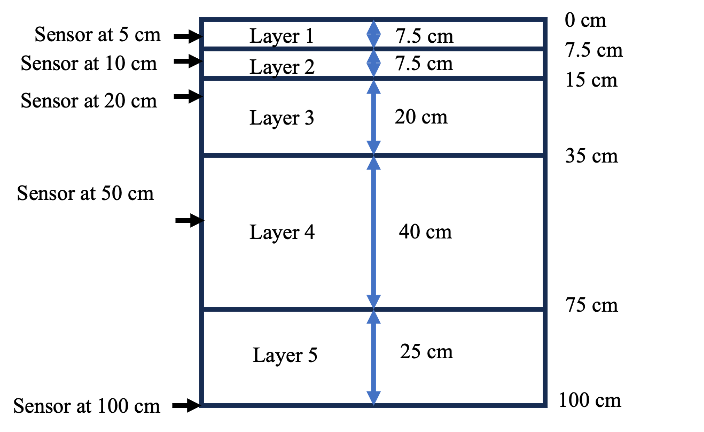

In [3]:
#Load from Excel
file_path = f'{data_dir}/Observational Data_sensors.xlsx'
stations = f'{data_dir}/stations.xlsx'
sheets_dict = pd.read_excel(file_path, sheet_name=None)
stations = pd.read_excel(stations, sheet_name='stations')
stations = stations.dropna(subset=[
    "Code",
    "Total Porosity (mm)",
    "Latitude",
    "Longitude"
])

print(sheets_dict.keys())
print(stations)

dict_keys(['BBC', 'BRW', 'BVL', 'CMI', 'DEK', 'DXS', 'FAI', 'FRE', 'FRM', 'ICC', 'LLC', 'MON', 'OLN', 'ORR', 'RND', 'SFM', 'SIU', 'SNI', 'STC', 'STE'])
        County        Station Code   Latitude  Longitude  Total Porosity (mm)  \
1      Fayette     Brownstown  BRW     38.949 -88.960000                504.0   
2    Champaign      Bondville  BVL     40.053 -88.371000                504.0   
3    Champaign      Champaign  CMI      40.08 -88.240000                543.0   
4       DeKalb        De Kalb  DEK     41.842 -88.851000                515.0   
5         Pope  Dixon Springs  DXS     37.437 -88.667000                486.0   
6        Wayne      Fairfield  FAI      38.38 -88.380000                403.5   
7   Stephenson       Freeport  FRE      42.29 -89.673000                481.5   
8   St. Claire     Belleville  FRM  38.516667 -89.883333                474.0   
9     Tazewell         Peoria  ICC       40.7 -89.533333                445.0   
10    Sangamon    Springfield  LLC  39

### Data Processing
This function converts the sensor data (%) to a cumulative soil moisture (mm) data 
Each sensor represents a layer whose top is halfway between the sensor above and current sensor
Layer bottom is halfway between the sensor below and current sensor

In [12]:
def convertsensordata(
    county_sensor: pd.DataFrame,
    code: str,
    tp_lookup: dict,
    lower_thresh: float = 150.0
) -> xr.DataArray:
    if code not in tp_lookup:
        raise KeyError(f"Station code '{code}' not found in tp_lookup (stations file).")

    upper_thresh = float(tp_lookup[code])
    #upper_thresh = 2000

    df = pd.DataFrame()
    df["time"] = pd.to_datetime(county_sensor[["Year", "Month", "Day"]])

    df["soilMoist"] = 10.0 * (
        county_sensor["sm5cm"]   * 7.5 +
        county_sensor["sm10cm"]  * 7.5 +
        county_sensor["sm20cm"]  * 20.0 +
        county_sensor["sm50cm"]  * 40.0 +
        county_sensor["sm100cm"] * 25.0
    )

    df = df.set_index("time").sort_index()
    df = df[~df.index.duplicated(keep="first")]

    da = df["soilMoist"].to_xarray()

    full_time = pd.date_range(start=da.time.values[0], end=da.time.values[-1], freq="D")
    da = da.reindex(time=full_time)

    # interpolate missing days (no extrapolation)
    da = da.interpolate_na(dim="time", method="linear")

    # -----------------------------
    # determine valid full-year window
    # start = first January 1 available in record
    # end   = last December 31 available in record
    # -----------------------------
    time_index = pd.to_datetime(da.time.values)

    jan1_mask = (time_index.month == 1) & (time_index.day == 1)
    dec31_mask = (time_index.month == 12) & (time_index.day == 31)

    jan1_dates = time_index[jan1_mask]
    dec31_dates = time_index[dec31_mask]

    if len(jan1_dates) == 0:
        raise ValueError(f"{code}: no January 1 found in record")
    if len(dec31_dates) == 0:
        raise ValueError(f"{code}: no December 31 found in record")

    startdate = jan1_dates[0]
    enddate = dec31_dates[-1]

    if startdate > enddate:
        raise ValueError(f"{code}: first available January 1 is after last available December 31")

    # convert calendar and slice
    da = da.convert_calendar("noleap")
    da = da.sel(time=slice(str(startdate.date()), str(enddate.date())))

    # -----------------------------
    # Threshold logic
    # -----------------------------
    vals = da.values.astype(float).copy()
    n = len(vals)

    invalid = (~np.isfinite(vals)) | (vals < lower_thresh) | (vals > upper_thresh)
    vals[invalid] = np.nan

    def within(x):
        return np.isfinite(x) and (lower_thresh <= x <= upper_thresh)

    for i in range(1, n - 1):
        if np.isnan(vals[i]):
            vp = vals[i - 1]
            vn = vals[i + 1]
            if within(vp) and within(vn):
                vals[i] = 0.5 * (vp + vn)

    da.data = vals

    # -----------------------------
    # Guarantee NO NaNs
    # -----------------------------
    da = da.ffill("time").bfill("time")

    if bool(da.isnull().any()):
        da = da.fillna(0.5 * (lower_thresh + upper_thresh))

    da = da.clip(min=lower_thresh, max=upper_thresh)

    # Attributes
    da.name = "soilMoist"
    da.attrs["units"] = "mm"
    da.attrs["lower_threshold_mm"] = float(lower_thresh)
    da.attrs["upper_threshold_mm"] = float(upper_thresh)
    da.attrs["station_code"] = str(code)
    da.attrs["start_date"] = str(startdate.date())
    da.attrs["end_date"] = str(enddate.date())
    da.attrs["nan_policy"] = "No NaNs: invalid->two-sided mean if possible->ffill/bfill->clip"

    return da

Applying the function to create a netcdf file that contains the latitude, longitude, station code and In-situ soil moisture values (thresholded). 

In [13]:
# =========================
# USER SETTINGS
# =========================
LOWER_THRESH = 150

# Output file
out_nc = f'{data_dir}/Insitu_soilMoist_daily_noleap_full_years.nc"

# -------------------------
# Lookups from stations file
# -------------------------
tp_lookup  = stations.set_index("Code")["Total Porosity (mm)"].to_dict()
lat_lookup = stations.set_index("Code")["Latitude"].to_dict()
lon_lookup = stations.set_index("Code")["Longitude"].to_dict()
# Get valid station codes AFTER cleaning
valid_codes = set(stations["Code"].astype(str))

print("Valid stations:", valid_codes)
# =========================
# Apply to all stations
# =========================
Insitu_raw = {}

for code, df_station in sheets_dict.items():

    # skip stations that were dropped
    if code not in valid_codes:
        print(f"Skipping {code} (not in cleaned stations)")
        continue

    Insitu_raw[code] = convertsensordata(
        df_station,
        code=code,
        tp_lookup=tp_lookup,
        lower_thresh=LOWER_THRESH,
    )
# =========================
# Combine into one Dataset (station, time)
# =========================
station_list = sorted(Insitu_raw.keys())

da_all = xr.concat(
    [Insitu_raw[code].assign_coords(station=code).expand_dims("station")
     for code in station_list],
    dim="station"
)

ds_out = da_all.to_dataset()

# Attach station-level coordinates
ds_out = ds_out.assign_coords(
    latitude=("station", [float(lat_lookup[c]) for c in ds_out.station.values]),
    longitude=("station", [float(lon_lookup[c]) for c in ds_out.station.values]),
)

# Global attrs
ds_out.attrs["description"] = "Daily in-situ soil moisture (mm), threshold filtered; full complete years only; noleap calendar"
ds_out.attrs["lower_threshold_mm"] = float(LOWER_THRESH)
ds_out.attrs["upper_threshold_source"] = "stations['Total Porosity (mm)'] by station Code"
ds_out.attrs["calendar"] = "noleap"
ds_out.attrs["period_note"] = "Each station starts on its first available January 1 and ends on its last available December 31"

# Save
ds_out.to_netcdf(out_nc)

print(f"Saved: {out_nc}")
print(ds_out)

Valid stations: {'DEK', 'RND', 'FAI', 'LLC', 'MON', 'DXS', 'SIU', 'FRM', 'ORR', 'STE', 'CMI', 'FRE', 'ICC', 'OLN', 'BVL', 'BRW', 'STC'}
Skipping BBC (not in cleaned stations)
Skipping SFM (not in cleaned stations)
Skipping SNI (not in cleaned stations)


/tmp/ipykernel_1490816/1348159702.py:42: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  da_all = xr.concat(


Saved: /data/keeling/a/tahsina2/Alam_et_al_2026/data/Insitu_soilMoist_daily_noleap_full_years_no_threshold.nc
<xarray.Dataset> Size: 1MB
Dimensions:    (time: 7300, station: 17)
Coordinates:
  * time       (time) object 58kB 2004-01-01 00:00:00 ... 2023-12-31 00:00:00
  * station    (station) <U3 204B 'BRW' 'BVL' 'CMI' 'DEK' ... 'SIU' 'STC' 'STE'
    latitude   (station) float64 136B 38.95 40.05 40.08 ... 37.7 41.9 40.42
    longitude  (station) float64 136B -88.96 -88.37 -88.24 ... -88.37 -89.32
Data variables:
    soilMoist  (station, time) float64 993kB 412.5 408.5 412.5 ... 380.5 380.7
Attributes:
    description:             Daily in-situ soil moisture (mm), threshold filt...
    lower_threshold_mm:      0.0
    upper_threshold_source:  stations['Total Porosity (mm)'] by station Code
    calendar:                noleap
    period_note:             Each station starts on its first available Janua...


#### Calculating % of outliers

In [11]:
# ============================================================
# PATHS
# ============================================================
file_path = f"{data_dir}/Observational Data_sensors.xlsx"
stations_path = f"{data_dir}/stations.xlsx"

out_csv = (
    f'{data_dir}/Insitu_outlier_percentage_above_total_porosity_pre2023.csv'
)

# ============================================================
# SETTINGS
# ============================================================
cutoff_date = pd.Timestamp("2022-12-31")

# ============================================================
# LOAD EXISTING FILES
# ============================================================
sheets_dict = pd.read_excel(file_path, sheet_name=None)

stations = pd.read_excel(stations_path, sheet_name="stations")
stations = stations.dropna(subset=[
    "Code",
    "Total Porosity (mm)",
    "Latitude",
    "Longitude"
])

stations["Code"] = stations["Code"].astype(str)

tp_lookup = stations.set_index("Code")["Total Porosity (mm)"].to_dict()
valid_codes = set(stations["Code"])

# ============================================================
# FUNCTION TO RECREATE RAW SOIL MOISTURE BEFORE FILTERING
# ============================================================
def calculate_raw_soil_moisture_mm(df):
    return 10.0 * (
        df["sm5cm"]   * 7.5 +
        df["sm10cm"]  * 7.5 +
        df["sm20cm"]  * 20.0 +
        df["sm50cm"]  * 40.0 +
        df["sm100cm"] * 25.0
    )

# ============================================================
# OUTLIER SUMMARY BEFORE 2023
# ============================================================
rows = []

total_valid_n = 0
total_outlier_n = 0

for code, df_station in sheets_dict.items():
    code = str(code)

    if code not in valid_codes:
        print(f"Skipping {code}: not in cleaned stations file")
        continue

    df_station = df_station.copy()

    df_station["time"] = pd.to_datetime(
        df_station[["Year", "Month", "Day"]],
        errors="coerce"
    )

    df_station = df_station[
        df_station["time"].notna() &
        (df_station["time"] <= cutoff_date)
    ].copy()

    if df_station.empty:
        print(f"Skipping {code}: no valid data on or before {cutoff_date.date()}")
        continue

    upper_thresh = float(tp_lookup[code])

    sm_raw = calculate_raw_soil_moisture_mm(df_station)
    sm_raw = np.asarray(sm_raw, dtype=float)

    valid_mask = np.isfinite(sm_raw)
    outlier_mask = valid_mask & (sm_raw > upper_thresh)

    n_valid = int(valid_mask.sum())
    n_outlier = int(outlier_mask.sum())

    pct_outlier = 100.0 * n_outlier / n_valid if n_valid > 0 else np.nan

    rows.append({
        "station": code,
        "start_date_used": df_station["time"].min().date(),
        "end_date_used": df_station["time"].max().date(),
        "total_porosity_mm": upper_thresh,
        "n_valid_raw_values": n_valid,
        "n_above_total_porosity": n_outlier,
        "percent_above_total_porosity": pct_outlier,
        "max_raw_soil_moisture_mm": float(np.nanmax(sm_raw)) if n_valid > 0 else np.nan,
    })

    total_valid_n += n_valid
    total_outlier_n += n_outlier

df_outliers = pd.DataFrame(rows).sort_values("station").reset_index(drop=True)

total_pct = 100.0 * total_outlier_n / total_valid_n if total_valid_n > 0 else np.nan

df_total = pd.DataFrame([{
    "station": "ALL_STATIONS",
    "start_date_used": np.nan,
    "end_date_used": cutoff_date.date(),
    "total_porosity_mm": np.nan,
    "n_valid_raw_values": total_valid_n,
    "n_above_total_porosity": total_outlier_n,
    "percent_above_total_porosity": total_pct,
    "max_raw_soil_moisture_mm": np.nan,
}])

df_outliers_final = pd.concat([df_outliers, df_total], ignore_index=True)

# ============================================================
# SAVE
# ============================================================
df_outliers_final.to_csv(out_csv, index=False)

print(df_outliers_final)
print(f"\nSaved: {out_csv}")

Skipping BBC: not in cleaned stations file
Skipping SFM: not in cleaned stations file
Skipping SNI: not in cleaned stations file
         station start_date_used end_date_used  total_porosity_mm  \
0            BRW      2003-02-18    2022-12-31              504.0   
1            BVL      2003-02-18    2022-12-31              504.0   
2            CMI      2003-02-18    2022-12-31              543.0   
3            DEK      2003-02-18    2022-12-31              515.0   
4            DXS      2003-02-18    2022-12-31              486.0   
5            FAI      2012-01-03    2022-12-31              403.5   
6            FRE      2003-02-18    2022-12-31              481.5   
7            FRM      2010-11-02    2022-12-31              474.0   
8            ICC      2010-09-14    2022-12-31              445.0   
9            LLC      2011-11-29    2022-12-31              499.0   
10           MON      2003-02-18    2022-12-31              504.0   
11           OLN      2011-06-01    2022-12

### Adding climatology (temperature and precipitation values) from either gridmet or livneh to the netcdf

In [16]:
# ----------------------------
# USER CHOICE: "gridmet" or "livneh"
# ----------------------------
climate_source = "gridmet"   # <-- change to "livneh" when needed
startdate = "2004-01-01"
enddate   = "2022-12-31"
# ----------------------------
# INPUT / OUTPUT PATHS
# ----------------------------
insitu_nc = f"{data_dir}/Insitu_soilMoist_daily_noleap_full_years.nc"  # your file
out_nc    = f"{data_dir}/Historical_Inputs.nc"

# ============================
# 1) Load insitu + rename variable
# ============================
ds_in = xr.open_dataset(insitu_nc)

# Rename soilMoist -> Insitu_sm
if "soilMoist" in ds_in.data_vars:
    ds_in = ds_in.rename({"soilMoist": "Insitu_sm"})
elif "Insitu_sm" not in ds_in.data_vars:
    raise KeyError(f"Expected 'soilMoist' in {insitu_nc}, found: {list(ds_in.data_vars)}")

# Ensure time slice (and keep this time as the master time axis)
ds_in = ds_in.sel(time=slice(startdate, enddate))

# Require station-level lat/lon in ds_in
if ("latitude" not in ds_in.coords) or ("longitude" not in ds_in.coords):
    raise KeyError("Insitu NetCDF must contain station coords 'latitude' and 'longitude'.")

# ============================
# 2) Load climate (Gridmet or Livneh) -> ds_clim with variables tas, pr and dim time
# ============================
def subset_conus(ds, lat_name="lat", lon_name="lon"):
    import regionmask
    countries = regionmask.defined_regions.natural_earth_v5_1_2.countries_50
    mask = countries.mask(ds[lon_name], ds[lat_name])
    mask_conus = mask == countries.map_keys("United States of America")

    ds_conus = ds.where(mask_conus, drop=True)
    ds_conus = ds_conus.where(
        (ds_conus[lat_name] <= 50) & (ds_conus[lon_name] > -130) & (ds_conus[lat_name] > 20),
        drop=True,
    )
    return ds_conus

if climate_source.lower() == "gridmet":
    # Read
    tmmn = xr.open_mfdataset(f"{clim_dir}/GRIDMET/tmmn/tmmn_*.nc", combine="by_coords")
    tmmx = xr.open_mfdataset(f"{clim_dir}/GRIDMET/tmmx/tmmx_*.nc", combine="by_coords")
    prcp = xr.open_mfdataset(f"{clim_dir}/GRIDMET/pr/pr_*.nc", combine="by_coords")

    # Subset
    tmmn_conus = subset_conus(tmmn, lat_name="lat", lon_name="lon")
    tmmx_conus = subset_conus(tmmx, lat_name="lat", lon_name="lon")
    prcp_conus = subset_conus(prcp, lat_name="lat", lon_name="lon")

    # Mean temperature
    tas_conus = 0.5 * (tmmn_conus + tmmx_conus)

    # Merge + calendar + rename
    ds_clim = xr.merge(
        [
            tas_conus.convert_calendar(calendar="noleap", dim="day"),
            prcp_conus.convert_calendar(calendar="noleap", dim="day"),
        ]
    )

    # Kelvin -> C (Gridmet air_temperature is usually Kelvin in your pipeline)
    if "air_temperature" in ds_clim:
        ds_clim["air_temperature"] = ds_clim["air_temperature"] - 273.15

    ds_clim = ds_clim.rename({"day": "time", "air_temperature": "tas", "precipitation_amount": "pr"})
    ds_clim = ds_clim.sel(time=slice(startdate, enddate))

elif climate_source.lower() == "livneh":
    # Read
    tas = xr.open_mfdataset(
        f"{clim_dir}/LIVNEH/tas/livneh_lusu_2020_temp_and_wind.2021-05-02.*.nc",
        combine="by_coords"
    )
    prcp = xr.open_mfdataset(
        f"{clim_dir}/LIVNEH/pr/livneh_unsplit_precip.2021-05-02.*.nc",
        combine="by_coords"
    )

    # Standardize names
    if "Time" in prcp.dims or "Time" in prcp.coords:
        prcp = prcp.rename({"Time": "time"})
    if "PRCP" in prcp.data_vars:
        prcp = prcp.rename({"PRCP": "pr"})

    # Subset
    tas_conus = subset_conus(tas, lat_name="lat", lon_name="lon")
    prcp_conus = subset_conus(prcp, lat_name="lat", lon_name="lon")

    # Build tas = mean(Tmax, Tmin)
    if ("Tmax" not in tas_conus.data_vars) or ("Tmin" not in tas_conus.data_vars):
        raise KeyError(f"LIVNEH tas file must contain Tmax and Tmin. Found: {list(tas_conus.data_vars)}")

    tas_conus = tas_conus.copy()
    tas_conus["tas"] = (tas_conus["Tmax"] + tas_conus["Tmin"]) / 2.0
    drop_vars = [v for v in ["Tmax", "Tmin", "Wind"] if v in tas_conus.data_vars]
    tas_conus = tas_conus.drop_vars(drop_vars)

    # Merge + calendar
    ds_clim = xr.merge(
        [
            tas_conus.convert_calendar(calendar="noleap", dim="time"),
            prcp_conus.convert_calendar(calendar="noleap", dim="time"),
        ]
    )

    ds_clim = ds_clim.sel(time=slice(startdate, enddate))

else:
    raise ValueError("climate_source must be 'gridmet' or 'livneh'.")

# ============================
# 3) Sample climate to stations (nearest grid cell)
#    Result dims: station, time
# ============================
# station coords from insitu file
st_lat = ds_in["latitude"]
st_lon = ds_in["longitude"]

tas_station = ds_clim["tas"].sel(lat=st_lat, lon=st_lon, method="nearest")
pr_station  = ds_clim["pr"].sel(lat=st_lat, lon=st_lon, method="nearest")

# Make sure dims are exactly (station, time)
tas_station = tas_station.transpose("station", "time")
pr_station  = pr_station.transpose("station", "time")

# ============================
# 4) Force full time coverage: if climate missing dates -> NaN
# ============================
master_time = ds_in["time"]

tas_station = tas_station.reindex(time=master_time)
pr_station  = pr_station.reindex(time=master_time)

if climate_source.lower() == "gridmet":
    tas_station.name = "Gridmet_tas"
    pr_station.name  = "Gridmet_pr"
elif climate_source.lower() == "livneh":
    tas_station.name = "Livneh_tas"
    pr_station.name  = "Livneh_pr"
else:
    raise ValueError("climate_source must be 'gridmet' or 'livneh'")

# Optional attrs
tas_station.attrs["units"] = "degC" if climate_source.lower() == "gridmet" else tas_station.attrs.get("units", "")
pr_station.attrs["units"]  = pr_station.attrs.get("units", "")

# ============================
# 5) Build Historical Inputs Dataset + save
# ============================
ds_hist = xr.Dataset(
    data_vars={
        "Insitu_sm": ds_in["Insitu_sm"],
        tas_station.name: tas_station,
        pr_station.name: pr_station,
    },
    coords={
        "station": ds_in["station"],
        "time": master_time,
        "latitude": ds_in["latitude"],
        "longitude": ds_in["longitude"],
    },
)

ds_hist.attrs["description"] = "Historical Inputs: In-situ soil moisture + station-sampled climate (tas, pr)"
ds_hist.attrs["climate_source"] = climate_source.lower()
ds_hist.attrs["period"] = f"{startdate} to {enddate}"
ds_hist.attrs["missing_dates_note"] = "tas/pr are reindexed to Insitu time; missing climate dates are NaN."
ds_hist = ds_hist.drop_vars(["lat", "lon"], errors="ignore")

# Force full computation into memory
ds_hist = ds_hist.load()

Adding the soil moisture and climate parameter values for each station from NLDAS or SMAP sources. Provided by Lafferty et al. (2025)

In [17]:
input_dir =data_dir

# Forcing files (must exist)
nldas_forcing_nc = f"{input_dir}/nldas_forcing.nc"
smap_forcing_nc  = f"{input_dir}/smap_forcing.nc"   # <-- set the real path if different

# Validation files (soil moisture variable is 'soilMoist')
VIC_nc    = f"{data_dir}/VIC_validation.nc"
MOSAIC_nc = f"{data_dir}/MOSAIC_validation.nc"
NOAH_nc   = f"{data_dir}/NOAH_validation.nc"
SMAP_nc   = f"{data_dir}/SMAP_validation.nc"

# ----------------------------
# Load Historical Inputs (master station/time)
# ----------------------------
master_time = ds_hist["time"]
st_lat = ds_hist["latitude"]
st_lon = ds_hist["longitude"]

# ----------------------------
# Helper: sample a dataset variable (tas/pr/soilMoist) to station coords and align to master_time
# Missing dates -> NaN
# ----------------------------
def sample_to_station_time(ds, varname, outname, master_time, st_lat, st_lon):
    if varname not in ds:
        raise KeyError(f"{varname} not found. Available: {list(ds.data_vars)}")

    da = ds[varname]

    # normalize time dimension name
    if "day" in da.dims and "time" not in da.dims:
        da = da.rename({"day": "time"})
    if "Time" in da.dims and "time" not in da.dims:
        da = da.rename({"Time": "time"})

    if "time" not in da.dims:
        raise ValueError(f"{outname}: no time dim found. dims={da.dims}")

    # sample to station points (expects ds has lat/lon dims)
    out = da.sel(lat=st_lat, lon=st_lon, method="nearest")

    # ensure expected dim order
    out = out.transpose("station", "time")

    # align to master time: anything outside coverage becomes NaN
    out = out.reindex(time=master_time)

    out.name = outname
    return out

# ----------------------------
# 1) Add NLDAS tas/pr
# ----------------------------
ds_nldas = xr.open_dataset(nldas_forcing_nc)

Nldas_tas = sample_to_station_time(ds_nldas, "tas", "Nldas_tas", master_time, st_lat, st_lon)
Nldas_pr  = sample_to_station_time(ds_nldas, "pr",  "Nldas_pr",  master_time, st_lat, st_lon)

# ----------------------------
# 2) Add SMAP tas/pr (from SMAP forcing file)
# ----------------------------
ds_smap_forcing = xr.open_dataset(smap_forcing_nc)

Smap_tas = sample_to_station_time(ds_smap_forcing, "tas", "Smap_tas", master_time, st_lat, st_lon)
Smap_pr  = sample_to_station_time(ds_smap_forcing, "pr",  "Smap_pr",  master_time, st_lat, st_lon)

# ----------------------------
# 3) Add validation soil moisture (variable name: soilMoist)
# ----------------------------
VIC    = xr.open_dataset(VIC_nc)
MOSAIC = xr.open_dataset(MOSAIC_nc)
NOAH   = xr.open_dataset(NOAH_nc)
SMAP   = xr.open_dataset(SMAP_nc)

VIC_sm    = sample_to_station_time(VIC,    "soilMoist", "VIC_sm",    master_time, st_lat, st_lon)
MOSAIC_sm = sample_to_station_time(MOSAIC, "soilMoist", "MOSAIC_sm", master_time, st_lat, st_lon)
NOAH_sm   = sample_to_station_time(NOAH,   "soilMoist", "NOAH_sm",   master_time, st_lat, st_lon)
SMAP_sm   = sample_to_station_time(SMAP,   "soilMoist", "SMAP_sm",   master_time, st_lat, st_lon)

# ----------------------------
# 4) Assign into Historical Inputs and save without dask
# ----------------------------
ds_hist = ds_hist.assign(
    Nldas_tas=Nldas_tas,
    Nldas_pr=Nldas_pr,
    Smap_tas=Smap_tas,
    Smap_pr=Smap_pr,
    VIC_sm=VIC_sm,
    MOSAIC_sm=MOSAIC_sm,
    NOAH_sm=NOAH_sm,
    SMAP_sm=SMAP_sm,
)

# Remove any laziness and write clean NetCDF
ds_hist = ds_hist.load()
ds_hist = ds_hist.drop_vars(["lat", "lon"], errors="ignore")
#encoding = {v: {"zlib": True, "complevel": 4} for v in ds_hist.data_vars}
ds_hist.to_netcdf(out_nc)

print(f"Saved: {out_nc}")
print(ds_hist)

Saved: /data/keeling/a/tahsina2/Alam_et_al_2026/data/Historical_Inputs.nc
<xarray.Dataset> Size: 8MB
Dimensions:      (time: 6935, station: 17)
Coordinates:
  * time         (time) object 55kB 2004-01-01 00:00:00 ... 2022-12-31 00:00:00
  * station      (station) <U3 204B 'BRW' 'BVL' 'CMI' ... 'SIU' 'STC' 'STE'
    latitude     (station) float64 136B 38.95 40.05 40.08 ... 37.7 41.9 40.42
    longitude    (station) float64 136B -88.96 -88.37 -88.24 ... -88.37 -89.32
    depth        float64 8B 50.0
Data variables:
    Insitu_sm    (station, time) float64 943kB 412.5 408.5 412.5 ... 343.7 347.4
    Gridmet_tas  (station, time) float64 943kB 5.85 14.35 8.75 ... 1.05 2.05
    Gridmet_pr   (station, time) float64 943kB 1.1 2.3 5.0 53.5 ... 1.2 0.0 0.0
    Nldas_tas    (station, time) float32 472kB nan nan nan ... 7.851 8.745 2.743
    Nldas_pr     (station, time) float32 472kB nan nan nan ... 0.0 0.0012 0.0
    Smap_tas     (station, time) float64 943kB nan nan nan ... 6.15 -0.003241
    Sm

### Creating a file with Station parameters

In [18]:
# -----------------------
# Paths / user settings
# -----------------------

STATIONS_XL = f"{data_dir}/stations.xlsx"
LON_NPY     = f"{data_dir}/eCONUS_lon.npy"
INPUTS_NPZ  = f"{data_dir}/inputs.npz"
OUT_NC      = f"{data_dir}/inputs_by_station_noleap.nc"

# NPZ time axis is daily noleap (365-day calendar)
STARTDATE = "2022-01-01"   # set to correct start for inputs.npz

VARS = [
    "awCap", "wiltingp", "rootDepth",
    "clayfrac", "sandfrac", "siltfrac",
    "soilMoist_init",
    "lai",
    "corn", "cotton", "rice", "sorghum", "soybeans", "durum_wheat", "spring_wheat",
    "cropland_other", "water",
    "evergreen_needleleaf", "evergreen_broadleaf",
    "deciduous_needleleaf", "deciduous_broadleaf",
    "mixed_forest", "woodland", "wooded_grassland",
    "closed_shurbland", "open_shrubland", "grassland",
    "barren", "urban",
    "elev_std",]

CORE_STATIC_CHECK = ["awCap", "wiltingp", "rootDepth"]

# -----------------------
# Helpers
# -----------------------
def _is_valid_number(x) -> bool:
    try:
        return np.isfinite(float(x))
    except Exception:
        return False

def to_lon180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def station_to_ij(lat0, lon0, lat_grid, lon_grid):
    lat0 = float(lat0)
    lon0 = float(lon0)
    lon0_180 = float(to_lon180(lon0))

    latg = np.asarray(lat_grid)
    long = np.asarray(lon_grid)

    # convert lon grid to [-180,180] if needed
    if np.nanmax(long) > 180.0:
        long_use = to_lon180(long)
    else:
        long_use = long

    if latg.ndim == 1 and long_use.ndim == 1:
        i = int(np.nanargmin(np.abs(latg - lat0)))
        j = int(np.nanargmin(np.abs(long_use - lon0_180)))
        return i, j

    if latg.ndim == 1 and long_use.ndim == 2:
        lat2 = np.repeat(latg[:, None], long_use.shape[1], axis=1)
        lon2 = long_use
    elif latg.ndim == 2 and long_use.ndim == 2:
        lat2 = latg
        lon2 = long_use
    else:
        raise ValueError("Unsupported lat/lon grid shapes for station_to_ij.")

    d2 = (lat2 - lat0) ** 2 + (lon2 - lon0_180) ** 2
    k = int(np.nanargmin(d2))
    i, j = np.unravel_index(k, d2.shape)
    return int(i), int(j)

def extract_at_ij(arr, i, j):
    a = np.asarray(arr)
    if a.ndim == 3:
        return a[:, i, j]          # (time, lat, lon)
    if a.ndim == 2:
        return a[i, j]             # (lat, lon)
    if a.ndim == 1:
        return a                   # vector (time) or something global
    raise ValueError(f"Unsupported array ndim={a.ndim}")

# -----------------------
# Main
# -----------------------
def main():
    stations = pd.read_excel(STATIONS_XL)

    if not {"Code", "Latitude", "Longitude"}.issubset(stations.columns):
        raise KeyError("stations.xlsx must contain columns: Code, Latitude, Longitude")

    stations = stations.loc[
        stations["Latitude"].apply(_is_valid_number) & stations["Longitude"].apply(_is_valid_number)
    ].copy()

    npz = np.load(INPUTS_NPZ, allow_pickle=True)
    lon_grid = np.load(LON_NPY)

    if "lats" not in npz.files:
        raise KeyError("inputs.npz must contain 'lats' key for latitude grid.")
    lat_grid = npz["lats"]

    # infer time length from tas/prcp/soilMoist_init (3D arrays)
    time_len = None
    for key in ["tas", "prcp", "soilMoist_init"]:
        if key in npz.files and np.asarray(npz[key]).ndim == 3:
            time_len = np.asarray(npz[key]).shape[0]
            break
    if time_len is None:
        raise ValueError("Could not infer time length (need tas/prcp/soilMoist_init as 3D arrays).")

    # Build noleap daily time coordinate (cftime objects)
    time = xr.cftime_range(start=STARTDATE, periods=time_len, freq="D", calendar="noleap")

    # containers
    codes, st_lats, st_lons, st_names, st_ctys = [], [], [], [], []
    collected = {v: [] for v in VARS if v in npz.files and v != "lats"}

    for _, row in stations.iterrows():
        code = str(row["Code"]).strip()
        lat0 = float(row["Latitude"])
        lon0 = float(row["Longitude"])

        try:
            i, j = station_to_ij(lat0, lon0, lat_grid, lon_grid)
        except Exception as e:
            print(f"Skip {code}: mapping failed: {e}")
            continue

        # skip if core statics are non-finite at this cell
        bad_cell = False
        for v in CORE_STATIC_CHECK:
            if v in npz.files:
                val = extract_at_ij(npz[v], i, j)
                if np.ndim(val) == 0:
                    ok = np.isfinite(float(val))
                else:
                    ok = np.isfinite(np.asarray(val)).all()
                if not ok:
                    bad_cell = True
                    break
        if bad_cell:
            print(f"Skip {code}: core static var non-finite at mapped cell (i={i},j={j})")
            continue

        codes.append(code)
        st_lats.append(lat0)
        st_lons.append(lon0)
        st_names.append(str(row["Station"]).strip() if "Station" in stations.columns else "")
        st_ctys.append(str(row["County"]).strip() if "County" in stations.columns else "")

        for v in list(collected.keys()):
            if v == "lai":
                lai = np.asarray(npz[v])
                if lai.ndim != 3:
                    raise ValueError(f"Expected lai to be 3D (365,lat,lon or time,lat,lon), got ndim={lai.ndim}")
                collected[v].append(lai[:, i, j])
                continue

            a = np.asarray(npz[v])
            if a.ndim in (2, 3):
                collected[v].append(extract_at_ij(a, i, j))
            elif a.ndim == 1:
                collected[v].append(a.copy())
            else:
                raise ValueError(f"Unsupported ndim for {v}: {a.ndim}")

    if len(codes) == 0:
        raise RuntimeError("No stations survived filtering/mapping. Check stations.xlsx and grids.")

    # coords
    station_coord = np.array(codes, dtype="U10")
    ds = xr.Dataset(
        coords={
            "station": station_coord,
            "time": time,
            "doy": np.arange(1, 366, dtype=int),
            "latitude": ("station", np.array(st_lats, dtype=np.float64)),
            "longitude": ("station", np.array(st_lons, dtype=np.float64)),
        }
    )

    ds["station_name"] = xr.DataArray(np.array(st_names, dtype="U64"), dims=("station",))
    ds["county"] = xr.DataArray(np.array(st_ctys, dtype="U64"), dims=("station",))

    # assign vars
    for v, lst in collected.items():
        ex = np.asarray(lst[0])

        if v == "lai":
            arr2 = np.stack([np.asarray(x) for x in lst], axis=0)  # (station, 365 or time_len)
            if arr2.shape[1] == 365:
                ds[v] = xr.DataArray(arr2.astype(np.float64), dims=("station", "doy"))
            elif arr2.shape[1] == time_len:
                ds[v] = xr.DataArray(arr2.astype(np.float64), dims=("station", "time"))
            else:
                raise ValueError(f"lai extracted length {arr2.shape[1]} not 365 and not time_len={time_len}")
            continue

        if ex.ndim == 0:
            ds[v] = xr.DataArray(np.array([float(x) for x in lst], dtype=np.float64), dims=("station",))
        elif ex.ndim == 1:
            arr2 = np.stack([np.asarray(x) for x in lst], axis=0)  # (station, time)
            if arr2.shape[1] != time_len:
                raise ValueError(f"{v} length {arr2.shape[1]} != time_len {time_len}")
            ds[v] = xr.DataArray(arr2.astype(np.float64), dims=("station", "time"))
        else:
            raise ValueError(f"Unexpected extracted shape for {v}: {ex.shape}")

    ds.attrs["description"] = "Station-extracted forcing + static maps from inputs.npz (nearest grid cell), noleap daily calendar"
    ds.attrs["inputs_npz"] = INPUTS_NPZ
    ds.attrs["lon_npy"] = LON_NPY
    ds.attrs["stations_xlsx"] = STATIONS_XL
    ds.attrs["startdate"] = STARTDATE
    ds.attrs["calendar"] = "noleap"
    ds.attrs["frequency"] = "D"
    ds.attrs["extraction_method"] = "nearest neighbor in lat/lon"
    ds.attrs["note_lai"] = "lai stored as station x doy if 365-long; else station x time"

    ds.to_netcdf(OUT_NC)
    print(f"Saved: {OUT_NC}")
    print(ds)

if __name__ == "__main__":
    main()

/tmp/ipykernel_580191/3453337364.py:119: DeprecationWarning: cftime_range() is deprecated, please use xarray.date_range(..., use_cftime=True) instead.
  time = xr.cftime_range(start=STARTDATE, periods=time_len, freq="D", calendar="noleap")


Saved: /data/keeling/a/tahsina2/Alam_et_al_2026/data//inputs_by_station_noleap.nc
<xarray.Dataset> Size: 69kB
Dimensions:               (station: 19, time: 317, doy: 365)
Coordinates:
  * station               (station) <U10 760B 'BBC' 'BRW' 'BVL' ... 'STC' 'STE'
  * time                  (time) object 3kB 2022-01-01 00:00:00 ... 2022-11-1...
  * doy                   (doy) int64 3kB 1 2 3 4 5 6 ... 361 362 363 364 365
    latitude              (station) float64 152B 41.63 38.95 ... 41.9 40.42
    longitude             (station) float64 152B -90.04 -88.96 ... -88.37 -89.32
Data variables: (12/32)
    station_name          (station) <U64 5kB 'Big Bend' ... 'Stelle'
    county                (station) <U64 5kB 'Whiteside' 'Fayette' ... 'Ford'
    awCap                 (station) float64 152B 149.6 184.4 ... 137.5 166.7
    wiltingp              (station) float64 152B 225.4 180.5 ... 268.2 218.8
    rootDepth             (station) float64 152B 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    clayfrac  

### Plotting
Plot the soil moisture/climate parameters values of a station

In [28]:
# ----------------------------
# INPUTS
# ----------------------------
station_nc = f"{data_dir}/Insitu_soilMoist_daily_noleap_full_years.nc"

# Illinois county shapefile
# Update this path to your county shapefile if needed
county_shp = f"{data_dir}/Illinois_County_Boundaries/IL_BNDY_County_Py.shp"

out_png = f"{plot_dir}/Fig21_Illinois_station_county_map.png"

# ----------------------------
# LOAD STATIONS
# ----------------------------
ds = xr.open_dataset(station_nc)

station_df = ds[["latitude", "longitude"]].to_dataframe().reset_index()

# keep one row per station
station_df = station_df[["station", "latitude", "longitude"]].drop_duplicates()

stations_gdf = gpd.GeoDataFrame(
    station_df,
    geometry=gpd.points_from_xy(station_df["longitude"], station_df["latitude"]),
    crs="EPSG:4326"
)

# ----------------------------
# LOAD COUNTIES
# ----------------------------
counties = gpd.read_file(county_shp)

# Reproject stations to county CRS
stations_gdf = stations_gdf.to_crs(counties.crs)

# Find county name column
print(counties.columns)

Index(['COUNTY_NAM', 'CO_FIPS', 'geometry'], dtype='object')


### Soil Moisture Station Map (Fig 2.1)

Using shapefile county column: COUNTY_NAM


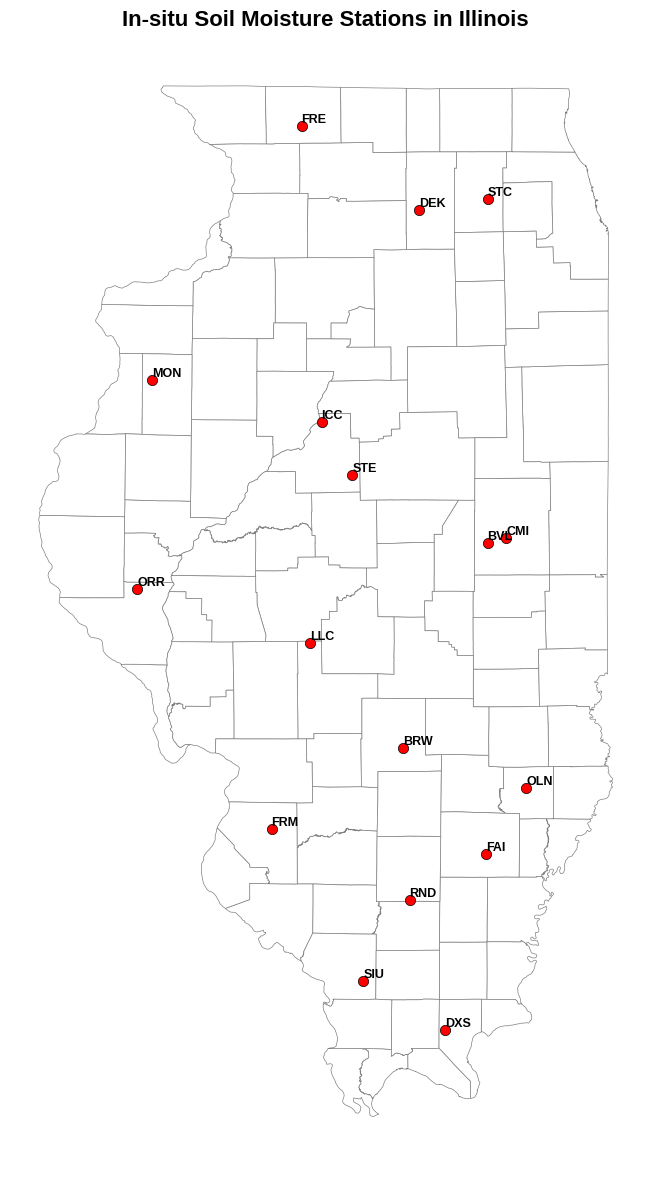

In [5]:

# ----------------------------
# INPUTS
# ----------------------------
station_nc = f"{data_dir}/Insitu_soilMoist_daily_noleap_full_years.nc"

stations_xlsx = f"{data_dir}/stations.xlsx"  # your stations file

county_shp = f"{data_dir}/Illinois_County_Boundaries/IL_BNDY_County_Py.shp"

out_png = f"{plot_dir}/Fig21_Illinois_station_county_map.png"

# ----------------------------
# LOAD STATIONS (lat/lon)
# ----------------------------
ds = xr.open_dataset(station_nc)

station_df = ds[["latitude", "longitude"]].to_dataframe().reset_index()
station_df = station_df[["station", "latitude", "longitude"]].drop_duplicates()

# ----------------------------
# LOAD STATION METADATA (county from Excel)
# ----------------------------
meta = pd.read_excel(stations_xlsx)

# Expected columns: Code, County (adjust if needed)
meta = meta.rename(columns={
    "Code": "station",
    "County": "county_name"
})

# Merge lat/lon with county info
station_df = station_df.merge(meta[["station", "county_name"]], on="station", how="left")

# ----------------------------
# GEO DATAFRAME
# ----------------------------
stations_gdf = gpd.GeoDataFrame(
    station_df,
    geometry=gpd.points_from_xy(
        station_df["longitude"],
        station_df["latitude"]
    ),
    crs="EPSG:4326"
)

# ----------------------------
# LOAD COUNTIES
# ----------------------------
counties = gpd.read_file(county_shp)
counties["geometry"] = counties.geometry.make_valid()

stations_gdf = stations_gdf.to_crs(counties.crs)

# ----------------------------
# FIND COUNTY NAME COLUMN IN SHAPEFILE
# ----------------------------
possible_cols = ["COUNTY_NAM", "COUNTY_NAME", "COUNTY", "NAME", "COUNTYNAME"]

county_name_col = None
for col in possible_cols:
    if col in counties.columns:
        county_name_col = col
        break

if county_name_col is None:
    raise KeyError(f"No county name column found. Columns: {list(counties.columns)}")

print(f"Using shapefile county column: {county_name_col}")

# ----------------------------
# FILTER ONLY COUNTIES THAT MATCH EXCEL
# ----------------------------
target_counties = station_df["county_name"].dropna().unique()

counties_with_stations = counties[
    counties[county_name_col].isin(target_counties)
].copy()

# Label positions
counties_with_stations["label_point"] = (
    counties_with_stations.geometry.representative_point()
)

# print("Counties from Excel:")
# print(sorted(target_counties))

# ----------------------------
# PLOT
# ----------------------------


plt.rcParams.update({
    "font.family": "Liberation Sans",
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

fig, ax = plt.subplots(figsize=(9, 12))

# Plot all county boundaries
counties.plot(
    ax=ax,
    facecolor="white",
    edgecolor="gray",
    linewidth=0.5
)

# Label ONLY counties from Excel
for _, row in counties_with_stations.iterrows():
    ax.text(
        row["label_point"].x,
        row["label_point"].y,
        str(row[county_name_col]),
        fontsize=14,
        ha="center",
        va="center"
    )

# Plot stations
stations_gdf.plot(
    ax=ax,
    color="red",
    markersize=55,
    edgecolor="black",
    linewidth=0.5,
    zorder=5
)

# Label station codes
for _, row in stations_gdf.iterrows():
    ax.text(
        row.geometry.x,
        row.geometry.y,
        str(row["station"]),
        fontsize=9,
        fontweight="bold",
        ha="left",
        va="bottom",
        zorder=6
    )

ax.set_title("In-situ Soil Moisture Stations in Illinois", fontsize=16, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.savefig(out_png, dpi=600, bbox_inches="tight")
plt.show()

#print(f"Saved: {out_png}")

### Historical Seasonal Cycle (Fig 3.1)

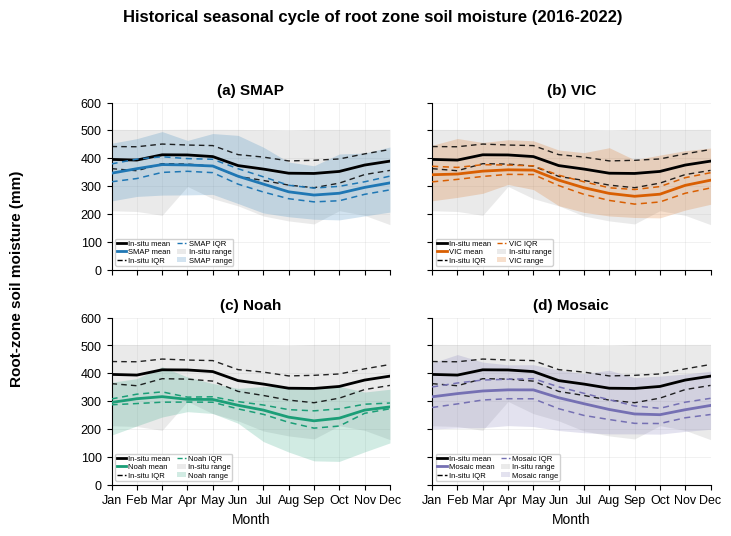

In [6]:

# --------------------------
# PATHS
# --------------------------

HIST_NC = f"{data_dir}/Historical_Inputs.nc"

os.makedirs(plot_dir, exist_ok=True)

# --------------------------
# SETTINGS
# --------------------------
STARTDATE = "2016-01-01"
ENDDATE   = "2022-12-31"

INSITU_VAR = "Insitu_sm"

DATA_VARS = {
    "SMAP": "SMAP_sm",
    "VIC": "VIC_sm",
    "Noah": "NOAH_sm",
    "Mosaic": "MOSAIC_sm",
}

product_colors = {
    "SMAP": "#1f77b4",
    "VIC": "#d95f02",
    "Noah": "#1b9e77",
    "Mosaic": "#7570b3",
}

insitu_color = "black"
insitu_fill = "gray"

months = np.arange(1, 13)
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# --------------------------
# STYLE
# --------------------------
plt.rcParams.update({
    "font.family": "Liberation Sans",
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# --------------------------
# FUNCTION
# --------------------------
def monthly_stats_over_stations_and_years(da):
    out = {"mean": [], "min": [], "max": [], "q25": [], "q75": []}

    for m in months:
        vals = da.where(da["time.month"] == m, drop=True).values
        vals = np.asarray(vals, dtype=float).ravel()
        vals = vals[np.isfinite(vals)]

        if vals.size == 0:
            for key in out:
                out[key].append(np.nan)
        else:
            out["mean"].append(np.mean(vals))
            out["min"].append(np.min(vals))
            out["max"].append(np.max(vals))
            out["q25"].append(np.percentile(vals, 25))
            out["q75"].append(np.percentile(vals, 75))

    return {k: np.asarray(v, dtype=float) for k, v in out.items()}

# --------------------------
# LOAD DATA
# --------------------------
ds = xr.open_dataset(HIST_NC)

insitu = ds[INSITU_VAR].sel(time=slice(STARTDATE, ENDDATE))
ins_stats = monthly_stats_over_stations_and_years(insitu)

# --------------------------
# PLOT
# --------------------------
fig, axes = plt.subplots(
    2, 2,
    figsize=(7.4, 5.6),
    sharex=True,
    sharey=True
)

axes = axes.flatten()
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for ax, panel, (label, varname) in zip(axes, panel_labels, DATA_VARS.items()):

    product = ds[varname].sel(time=slice(STARTDATE, ENDDATE))
    product_stats = monthly_stats_over_stations_and_years(product)

    product_color = product_colors[label]

    # --------------------------
    # In-situ min-max range
    # --------------------------
    ax.fill_between(
        months,
        ins_stats["min"],
        ins_stats["max"],
        color=insitu_fill,
        alpha=0.16,
        linewidth=0,
        zorder=1
    )

    # In-situ IQR bounds
    ax.plot(
        months,
        ins_stats["q25"],
        color=insitu_color,
        linewidth=1.0,
        linestyle="--",
        dashes=(4, 3),
        alpha=0.85,
        zorder=3
    )
    ax.plot(
        months,
        ins_stats["q75"],
        color=insitu_color,
        linewidth=1.0,
        linestyle="--",
        dashes=(4, 3),
        alpha=0.85,
        zorder=3
    )

    # In-situ mean
    ax.plot(
        months,
        ins_stats["mean"],
        color=insitu_color,
        linewidth=2.0,
        zorder=4
    )

    # --------------------------
    # Product min-max range
    # --------------------------
    ax.fill_between(
        months,
        product_stats["min"],
        product_stats["max"],
        color=product_color,
        alpha=0.20,
        linewidth=0,
        zorder=2
    )

    # Product IQR bounds
    ax.plot(
        months,
        product_stats["q25"],
        color=product_color,
        linewidth=1.1,
        linestyle="--",
        dashes=(4, 3),
        zorder=5
    )
    ax.plot(
        months,
        product_stats["q75"],
        color=product_color,
        linewidth=1.1,
        linestyle="--",
        dashes=(4, 3),
        zorder=5
    )

    # Product mean
    ax.plot(
        months,
        product_stats["mean"],
        color=product_color,
        linewidth=2.0,
        zorder=6
    )

    ax.set_title(f"{panel} {label}", fontweight="bold")
    ax.grid(True, linewidth=0.4, alpha=0.30)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # --------------------------
    # Panel-specific legend
    # --------------------------
    legend_elements = [
        Line2D([0], [0], color="black", lw=2,
               label="In-situ mean"),
        Line2D([0], [0], color=product_color, lw=2,
               label=f"{label} mean"),
    
        Line2D([0], [0], color="black", lw=1,
               linestyle="--", label="In-situ IQR"),
        Line2D([0], [0], color=product_color, lw=1,
               linestyle="--", label=f"{label} IQR"),
    
        Patch(facecolor="gray", alpha=0.16,
              label="In-situ range"),
        Patch(facecolor=product_color, alpha=0.20,
              label=f"{label} range"),
    ]
    
    ax.legend(
        handles=legend_elements,
        loc="lower left",      # try lower left first
        ncol=2,                # 2 columns instead of 1
        fontsize=5.5,
        frameon=True,
        framealpha=0.9,
        borderpad=0.2,
        labelspacing=0.15,
        handlelength=1.2,
        handletextpad=0.3,
        columnspacing=0.8
    )

# --------------------------
# AXES
# --------------------------
for ax in axes:
    ax.set_xlim(1, 12)
    ax.set_ylim(0, 600)
    ax.set_xticks(months)
    ax.set_xticklabels(month_labels)

for ax in axes[2:]:
    ax.set_xlabel("Month")

fig.supylabel(
    "Root-zone soil moisture (mm)",
    fontsize=11,
    fontweight="bold",
    x=0.01
)

fig.suptitle(
    "Historical seasonal cycle of root zone soil moisture (2016-2022)",
    fontsize=12,
    fontweight="bold",
    y=0.98
)

plt.tight_layout(rect=[0.03, 0.02, 1, 0.95])

# --------------------------
# SAVE
# --------------------------
save_png = os.path.join(
    plot_dir,
    "Fig31_seasonal_cycle_products_vs_insitu_4panel_journal_panel_legends.png"
)

save_pdf = save_png.replace(".png", ".pdf")

fig.savefig(save_png, dpi=600, bbox_inches="tight")
#fig.savefig(save_pdf, bbox_inches="tight")

ds.close()
plt.show()

### Statistical Summary (Table 2.1)

In [25]:
# ----------------------------
# Paths
# ----------------------------
hist_nc = f"{data_dir}/Historical_Inputs.nc"
out_csv = f"{table_dir}/Table21_Station_SoilMoisture_Summary.csv"

# ----------------------------
# Load ds_hist (use existing if present)
# ----------------------------
if "ds_hist" not in globals():
    if not os.path.exists(hist_nc):
        raise FileNotFoundError(f"Not found: {hist_nc}")
    ds_hist = xr.open_dataset(hist_nc)

# ----------------------------
# Load stations (use existing if present)
# ----------------------------
if "stations" not in globals():
    raise NameError("`stations` is not in memory. Load it first (pd.read_excel / pd.read_csv).")

# If stations is a dict of sheets, take the first sheet
stations_df = list(stations.values())[0] if isinstance(stations, dict) else stations.copy()

# ----------------------------
# Compute Insitu_sm mean/std per station
# ----------------------------
if "Insitu_sm" not in ds_hist.data_vars:
    raise KeyError(f"'Insitu_sm' not found in ds_hist. Found: {list(ds_hist.data_vars)}")

insitu = ds_hist["Insitu_sm"]
mean_sm = insitu.mean(dim="time", skipna=True).to_pandas()
std_sm  = insitu.std(dim="time", skipna=True).to_pandas()

stats_df = pd.DataFrame({
    "Code": mean_sm.index.astype(str),
    "Average Daily Soil Moisture (mm)": mean_sm.values,
    "Standard Deviation of Daily Soil Moisture (mm)": std_sm.values,
})

# ----------------------------
# Merge with stations metadata
# ----------------------------
required_cols = [
    "County", "Station", "Code", "Latitude", "Longitude",
    "Soil Texture", "Total Porosity (mm)"
]
missing = [c for c in required_cols if c not in stations_df.columns]
if missing:
    raise KeyError(f"Stations table missing columns: {missing}. Available: {list(stations_df.columns)}")

meta_df = stations_df[required_cols].copy()
meta_df["Code"] = meta_df["Code"].astype(str)

out = meta_df.merge(stats_df, on="Code", how="inner")

# ----------------------------
# Keep only valid lat/lon
# ----------------------------
out["Latitude"]  = pd.to_numeric(out["Latitude"], errors="coerce")
out["Longitude"] = pd.to_numeric(out["Longitude"], errors="coerce")
out = out.dropna(subset=["Latitude", "Longitude"])

# ----------------------------
# Round to 2 decimals
# ----------------------------
num_cols = [
    "Latitude", "Longitude", "Total Porosity (mm)",
    "Average Daily Soil Moisture (mm)",
    "Standard Deviation of Daily Soil Moisture (mm)"
]
for c in num_cols:
    out[c] = pd.to_numeric(out[c], errors="coerce")

out[num_cols] = out[num_cols].round(2)

# ----------------------------
# Add serial column and order
# ----------------------------
out = out.sort_values(["County", "Station", "Code"]).reset_index(drop=True)
out.insert(0, "Sl.", np.arange(1, len(out) + 1))

out = out[[
    "Sl.", "County", "Station", "Code", "Latitude", "Longitude",
    "Soil Texture", "Total Porosity (mm)",
    "Average Daily Soil Moisture (mm)",
    "Standard Deviation of Daily Soil Moisture (mm)"
]]

# ----------------------------
# Save + print
# ----------------------------
out.to_csv(out_csv, index=False)

pd.set_option("display.float_format", "{:.2f}".format)
print(out)

print(f"\nSaved CSV: {out_csv}")

    Sl.      County        Station Code  Latitude  Longitude    Soil Texture  \
0     1   Champaign      Bondville  BVL     40.05     -88.37       Silt Loam   
1     2   Champaign      Champaign  CMI     40.08     -88.24  Silt Clay Loam   
2     3      DeKalb        De Kalb  DEK     41.84     -88.85       Silt Loam   
3     4     Fayette     Brownstown  BRW     38.95     -88.96       Silt Loam   
4     5        Ford         Stelle  STE     40.42     -89.32       Silt Loam   
5     6     Jackson     Carbondale  SIU     37.70     -89.24       Silt Loam   
6     7   Jefferson      Rand Lake  RND     38.13     -88.92       Silt Loam   
7     8        Kane    St. Charles  STC     41.90     -88.37       Silt Loam   
8     9        Pike          Perry  ORR     39.81     -90.82       Silt Loam   
9    10        Pope  Dixon Springs  DXS     37.44     -88.67       Silt Loam   
10   11    Richland          Olney  OLN     38.73     -88.10       Silt Loam   
11   12    Sangamon    Springfield  LLC 

### Analysis based on Soil Texture and Land Use type

,station,texture,sand,silt,clay,mean_sm,std_sm,cv_sm,range_sm
0,BRW,loam,0.412402,0.356637,0.230916,327.052925,50.564267,0.154606,135.333270
1,BVL,silt loam,0.123069,0.625962,0.250969,352.107389,49.195714,0.139718,136.961997
2,CMI,silt loam,0.172103,0.603747,0.224150,349.846188,51.426287,0.146997,143.509817
3,DEK,clay loam,0.218269,0.503069,0.278359,321.893144,50.025507,0.155410,136.435974
4,DXS,loam,0.383899,0.369791,0.246333,306.994218,61.436803,0.200124,164.586636
5,FAI,loam,0.457686,0.330698,0.211572,335.935023,52.160906,0.155271,141.995460
6,FRE,silty clay loam,0.135642,0.591734,0.272624,363.661039,55.234835,0.151885,142.847288
7,FRM,silty clay loam,0.124150,0.587405,0.289608,325.145862,48.673887,0.149699,133.159375
8,ICC,silt loam,0.200894,0.561498,0.234118,299.770751,40.460648,0.134972,108.840835
9,LLC,silty clay loam,0.180185,0.545114,0.274713,330.523656,49.926529,0.151053,134.517771


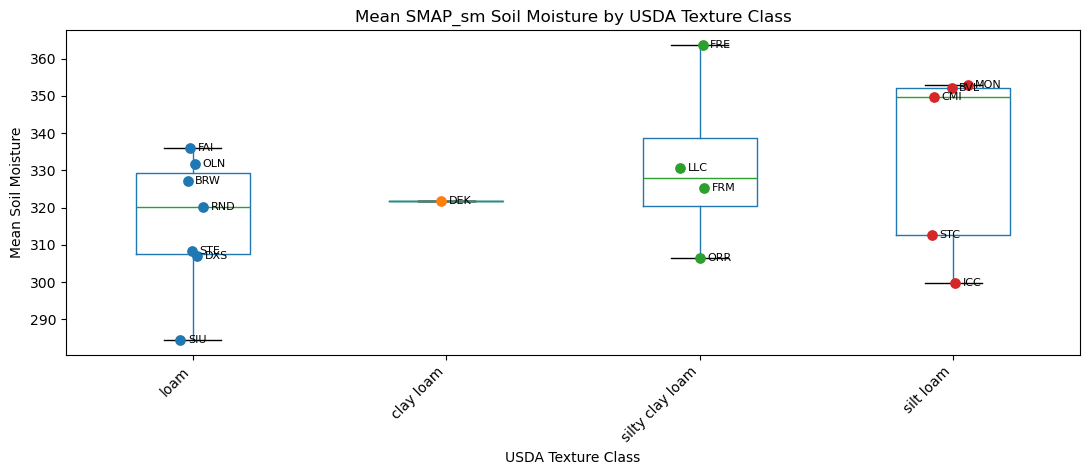

In [23]:
# ============================================================
# LOAD DATA
# ============================================================


ds_inputs = xr.open_dataset(
    f"{data_dir}/inputs_by_station_noleap.nc"
)

ds_hist = xr.open_dataset(
    f"{data_dir}/Historical_Inputs.nc"
)

SM_VAR = "SMAP_sm"

rows = []

input_stations = [str(s).strip() for s in ds_inputs.station.values]
hist_stations  = [str(s).strip() for s in ds_hist.station.values]

stations = sorted(set(input_stations).intersection(hist_stations))

rows = []

for st in stations:

    sm = (
        ds_hist[SM_VAR]
        .sel(station=st)
        .sel(time=slice("2016-01-01", "2022-12-31"))
        .values
    )

    sm = sm[np.isfinite(sm)]

    if len(sm) == 0:
        continue

    sand = float(ds_inputs["sandfrac"].sel(station=st).values)
    silt = float(ds_inputs["siltfrac"].sel(station=st).values)
    clay = float(ds_inputs["clayfrac"].sel(station=st).values)

    texture = getTexture(
        sand * 100,
        clay * 100,
        classification="USDA"
    )

    rows.append({
        "station": st,
        "texture": texture,
        "sand": sand,
        "silt": silt,
        "clay": clay,
        "mean_sm": np.mean(sm),
        "std_sm": np.std(sm),
        "cv_sm": np.std(sm) / np.mean(sm),
        "range_sm": np.percentile(sm, 90) - np.percentile(sm, 10),
    })

df = pd.DataFrame(rows)

display(df)

# ============================================================
# BOXPLOT WITH STATION POINTS + LABELS
# ============================================================

order = (
    df.groupby("texture")["mean_sm"]
      .median()
      .sort_values()
      .index
      .tolist()
)

df["texture"] = pd.Categorical(
    df["texture"],
    categories=order,
    ordered=True
)

fig, ax = plt.subplots(figsize=(11, 5))

df.boxplot(
    column="mean_sm",
    by="texture",
    grid=False,
    ax=ax
)

# Add station points and labels
for i, tex in enumerate(order, start=1):

    temp = df[df["texture"] == tex].copy()

    # small horizontal jitter so points do not overlap
    x_jitter = np.random.normal(
        loc=i,
        scale=0.04,
        size=len(temp)
    )

    ax.scatter(
        x_jitter,
        temp["mean_sm"],
        s=45,
        zorder=3
    )

    for x, (_, r) in zip(x_jitter, temp.iterrows()):
        ax.text(
            x + 0.03,
            r["mean_sm"],
            r["station"],
            fontsize=8,
            va="center"
        )

ax.set_xlabel("USDA Texture Class")
ax.set_ylabel("Mean Soil Moisture")
ax.set_title(f"Mean {SM_VAR} Soil Moisture by USDA Texture Class")
fig.suptitle("")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Skipping BBC (not in Historical_Inputs)
Skipping SFM (not in Historical_Inputs)


,station,land_type,mean_sm,std_sm,cropland_frac,forestland_frac
0,BRW,Cropland,327.052925,50.564267,0.684932,0.315068
1,BVL,Forestland,352.107389,49.195714,0.007042,0.992958
2,CMI,Forestland,349.846188,51.426287,0.013986,0.986014
3,DEK,Forestland,321.893144,50.025507,0.000000,1.000000
4,DXS,Cropland,306.994218,61.436803,0.891156,0.108844
5,FAI,Cropland,335.935023,52.160906,0.918519,0.081481
6,FRE,Cropland,363.661039,55.234835,0.620690,0.365517
7,FRM,Forestland,325.145862,48.673887,0.383459,0.616541
8,ICC,Forestland,299.770751,40.460648,0.393103,0.606897
9,LLC,Cropland,330.523656,49.926529,0.909091,0.090909


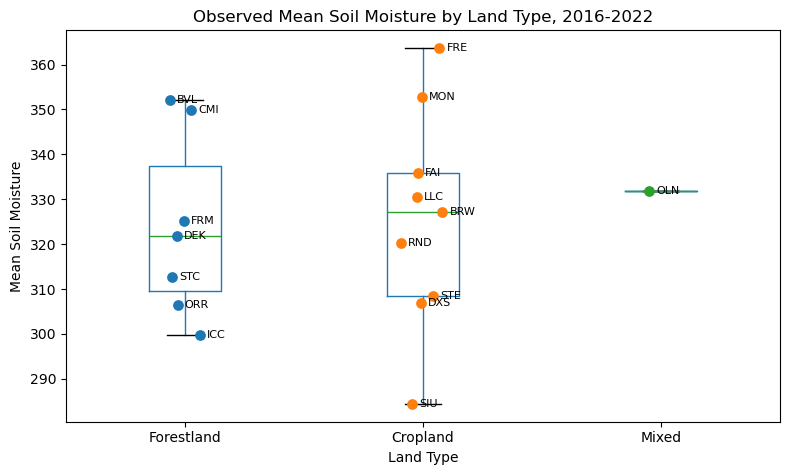

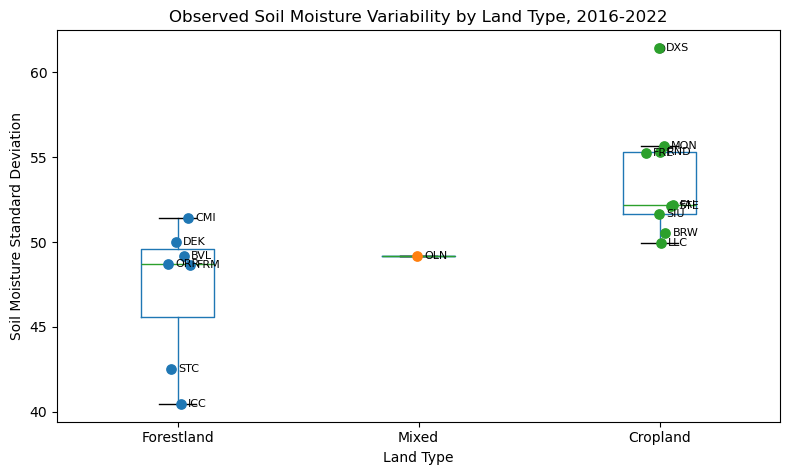

In [25]:
ds = xr.open_dataset(
    f"{data_dir}/inputs_by_station_noleap.nc"
)

rows = []

for st in ds.station.values:

    st = str(st)

    def get(v):
        return float(ds[v].sel(station=st)) if v in ds else 0.0

    cropland = (
        get("corn")
        + get("cotton")
        + get("rice")
        + get("sorghum")
        + get("soybeans")
        + get("durum_wheat")
        + get("spring_wheat")
        + get("cropland_other")
    )

    forestland = (
        get("evergreen_needleleaf")
        + get("evergreen_broadleaf")
        + get("deciduous_needleleaf")
        + get("deciduous_broadleaf")
        + get("mixed_forest")
        + get("woodland")
        + get("wooded_grassland")
    )

    if cropland >= 0.6:
        land_type = "Cropland"
    elif forestland >= 0.6:
        land_type = "Forestland"
    else:
        land_type = "Mixed"

    rows.append({
        "station": st,
        "cropland_frac": cropland,
        "forestland_frac": forestland,
        "land_type": land_type,
    })

land_df = pd.DataFrame(rows)

#display(land_df)


hist = xr.open_dataset(
    f"{data_dir}/Historical_Inputs.nc"
)

rows = []

hist_stations = {
    str(s).strip()
    for s in hist.station.values
}

for _, r in land_df.iterrows():

    st = str(r["station"]).strip()

    if st not in hist_stations:
        print(f"Skipping {st} (not in Historical_Inputs)")
        continue

    sm = (
        hist["SMAP_sm"]
        .sel(station=st)
        .sel(time=slice("2016-01-01", "2022-12-31"))
        .values
    )

    sm = sm[np.isfinite(sm)]

    if len(sm) == 0:
        continue

    rows.append({
        "station": st,
        "land_type": r["land_type"],
        "mean_sm": np.mean(sm),
        "std_sm": np.std(sm),
    })

sm_df = pd.DataFrame(rows)

#display(sm_df)

df = sm_df.merge(
    land_df,
    on=["station", "land_type"],
    how="left"
)

display(df)

# ============================================================
# BOXPLOT WITH STATION POINTS + LABELS
# ============================================================

def boxplot_with_station_points(df, column, ylabel, title):
    order = (
        df.groupby("land_type")[column]
          .median()
          .sort_values()
          .index
          .tolist()
    )

    df_plot = df.copy()
    df_plot["land_type"] = pd.Categorical(
        df_plot["land_type"],
        categories=order,
        ordered=True
    )

    fig, ax = plt.subplots(figsize=(8, 5))

    df_plot.boxplot(
        column=column,
        by="land_type",
        grid=False,
        ax=ax
    )

    for i, land_type in enumerate(order, start=1):
        temp = df_plot[df_plot["land_type"] == land_type].copy()

        x_jitter = np.random.normal(
            loc=i,
            scale=0.04,
            size=len(temp)
        )

        ax.scatter(
            x_jitter,
            temp[column],
            s=45,
            zorder=3
        )

        for x, (_, r) in zip(x_jitter, temp.iterrows()):
            ax.text(
                x + 0.03,
                r[column],
                r["station"],
                fontsize=8,
                va="center"
            )

    ax.set_xlabel("Land Type")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.suptitle("")

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


boxplot_with_station_points(
    df=df,
    column="mean_sm",
    ylabel="Mean Soil Moisture",
    title="Observed Mean Soil Moisture by Land Type, 2016-2022"
)

boxplot_with_station_points(
    df=df,
    column="std_sm",
    ylabel="Soil Moisture Standard Deviation",
    title="Observed Soil Moisture Variability by Land Type, 2016-2022"
)

   station       group
0      BRW    Cropland
14     SIU    Cropland
13     RND    Cropland
11     OLN    Cropland
10     MON    Cropland
9      LLC    Cropland
16     STE    Cropland
5      FAI    Cropland
4      DXS    Cropland
6      FRE    Cropland
7      FRM  Forestland
15     STC  Forestland
3      DEK  Forestland
12     ORR  Forestland
2      CMI  Forestland
1      BVL  Forestland
8      ICC  Forestland


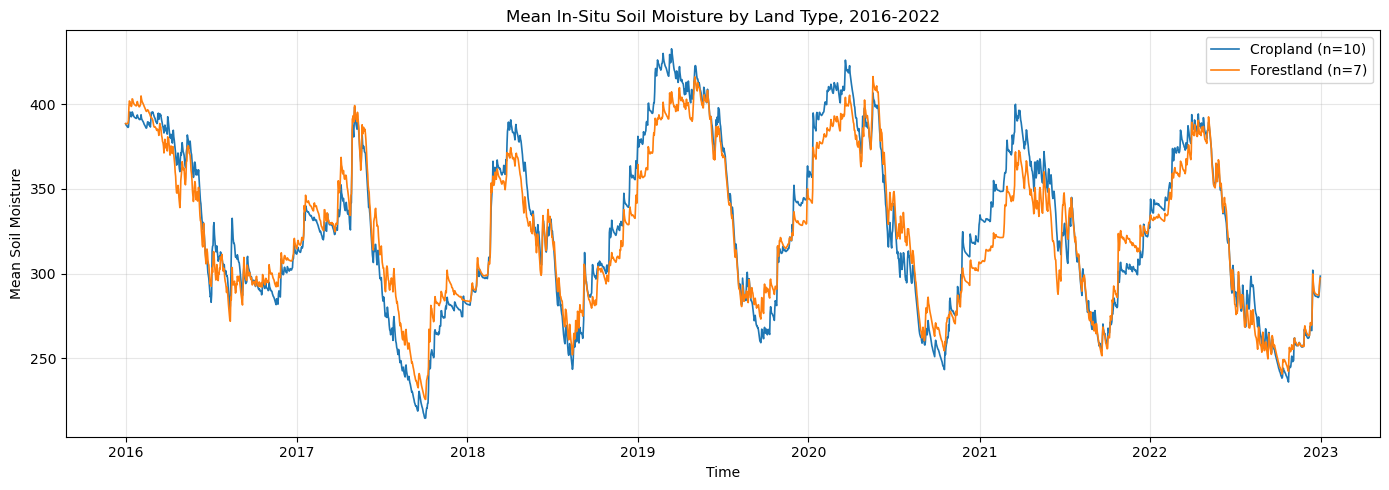

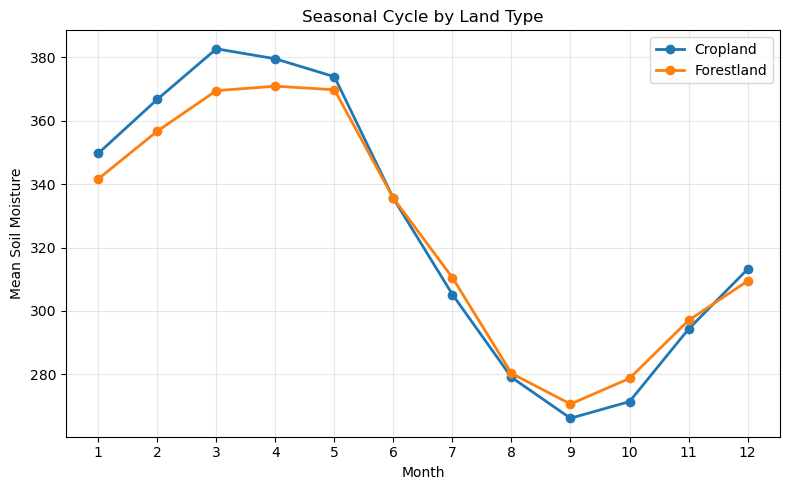

In [20]:

# ============================================================
# LOAD DATA
# ============================================================


ds_inputs = xr.open_dataset(
    f"{data_dir}/inputs_by_station_noleap.nc"
)

hist = xr.open_dataset(
   f"{data_dir}/Historical_Inputs.nc"
)

# ============================================================
# STATION INTERSECTION
# ============================================================
input_stations = {
    str(s).strip()
    for s in ds_inputs.station.values
}

hist_stations = {
    str(s).strip()
    for s in hist.station.values
}

stations = sorted(input_stations & hist_stations)

# ============================================================
# CLASSIFY STATIONS
# ============================================================
station_groups = {}

for st in stations:

    def get(v):
        if v not in ds_inputs:
            return 0.0

        return float(
            ds_inputs[v]
            .sel(station=st)
            .values
        )

    cropland = (
        get("corn")
        + get("cotton")
        + get("rice")
        + get("sorghum")
        + get("soybeans")
        + get("durum_wheat")
        + get("spring_wheat")
        + get("cropland_other")
    )

    forestland = (
        get("evergreen_needleleaf")
        + get("evergreen_broadleaf")
        + get("deciduous_needleleaf")
        + get("deciduous_broadleaf")
        + get("mixed_forest")
        + get("woodland")
        + get("wooded_grassland")
    )

    if cropland >= 0.50:
        station_groups[st] = "Cropland"
    elif forestland >= 0.50:
        station_groups[st] = "Forestland"
    else:
        station_groups[st] = "Mixed"

# ============================================================
# PRINT GROUP MEMBERSHIP
# ============================================================
group_df = pd.DataFrame({
    "station": list(station_groups.keys()),
    "group": list(station_groups.values())
})

print(group_df.sort_values("group"))

# ============================================================
# BUILD DAILY GROUP MEANS
# ============================================================
group_series = {}

for group in ["Cropland", "Mixed", "Forestland"]:

    group_stations = [
        st
        for st, g in station_groups.items()
        if g == group
    ]

    if len(group_stations) == 0:
        continue

    da = (
        hist["SMAP_sm"]
        .sel(station=group_stations)
        .sel(time=slice("2016-01-01", "2022-12-31"))
    )

    group_series[group] = da.mean(
        dim="station",
        skipna=True
    )

# ============================================================
# PLOT DAILY MEAN TIME SERIES
# Handles cftime.DatetimeNoLeap safely
# ============================================================

plt.figure(figsize=(14, 5))

for group, da in group_series.items():

    # Convert cftime/no-leap time to string dates, then pandas datetime
    time = pd.to_datetime([str(t)[:10] for t in da.time.values])

    plt.plot(
        time,
        da.values,
        linewidth=1.2,
        label=f"{group} (n={len([s for s, g in station_groups.items() if g == group])})"
    )

plt.xlabel("Time")
plt.ylabel("Mean Soil Moisture")
plt.title("Mean In-Situ Soil Moisture by Land Type, 2016-2022")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# MONTHLY CLIMATOLOGY
# ============================================================

plt.figure(figsize=(8, 5))

for group, da in group_series.items():

    # Build dataframe to avoid cftime plotting issues
    temp = pd.DataFrame({
        "time": pd.to_datetime([str(t)[:10] for t in da.time.values]),
        "soil_moisture": da.values,
    })

    temp["month"] = temp["time"].dt.month

    monthly = (
        temp.groupby("month")["soil_moisture"]
        .mean()
        .reset_index()
    )

    plt.plot(
        monthly["month"],
        monthly["soil_moisture"],
        marker="o",
        linewidth=2,
        label=group
    )

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Mean Soil Moisture")
plt.title("Seasonal Cycle by Land Type")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()